In [1]:
!kaggle datasets download -d olistbr/brazilian-ecommerce --unzip

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:00<00:00, 156MB/s]



In [2]:
import os
os.listdir()

['.config',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_customers_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv',
 'olist_products_dataset.csv',
 'olist_geolocation_dataset.csv',
 'sample_data']

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_payments = pd.read_csv('olist_order_payments_dataset.csv')
df_customers = pd.read_csv('olist_customers_dataset.csv')

In [5]:
df_orders.shape

(99441, 8)

In [6]:
df_payments.shape

(103886, 5)

In [7]:
df_customers.shape

(99441, 5)

In [8]:
print("=== ЗАКАЗЫ ===")
print(df_orders.head())
print("\n=== ПЛАТЕЖИ ===")
print(df_payments.head())
print("\n=== КЛИЕНТЫ ===")
print(df_customers.head())

=== ЗАКАЗЫ ===
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00   

In [9]:
df1 = df_orders.merge(df_payments, on='order_id',how='inner')
df1 = df1.merge(df_customers, on='customer_id',how='inner')
print(df1.shape)
df1.head()

(103886, 16)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,1,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,1,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,1,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [10]:
df_payments_agg = df_payments.groupby('order_id')['payment_value'].sum().reset_index()
print(df_payments_agg.shape)

(99440, 2)


In [11]:
df1 = df_orders.merge(df_payments_agg, on='order_id',how='inner')
df1 = df1.merge(df_customers, on='customer_id',how='inner')
print(df1.shape)
df1.head()

(99440, 13)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,38.71,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,72.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,28.62,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [12]:
df_rfm = df1[['order_purchase_timestamp', 'customer_unique_id', 'payment_value']]

In [13]:
print(df_rfm.shape)
df_rfm.head()

(99440, 3)


,order_purchase_timestamp,customer_unique_id,payment_value
0,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,38.71
1,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,141.46
2,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,179.12
3,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,72.20
4,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,28.62


In [14]:
df_rfm.isnull().sum()

,0
order_purchase_timestamp,0
customer_unique_id,0
payment_value,0


In [15]:
df_rfm.duplicated().sum()

np.int64(41)

In [16]:
df_rfm = df_rfm.drop_duplicates()

In [17]:
df_rfm.shape

(99399, 3)

In [18]:
df_rfm[df_rfm['payment_value'] < 0].shape

(0, 3)

In [19]:
df_rfm.shape

(99399, 3)

## Data Loading & Cleaning

Three datasets were loaded from the Olist Brazilian E-Commerce collection:
- `olist_orders_dataset.csv` (99,441 × 8)
- `olist_order_payments_dataset.csv` (103,886 × 5)
- `olist_customers_dataset.csv` (99,441 × 5)

**Merging:** Orders were joined with payments on `order_id` and with customers on `customer_id`.

**Payment aggregation:** `df_payments` was grouped by `order_id` and `payment_value` was summed to resolve ambiguities caused by multiple payment methods per order.

**Columns selected for RFM analysis:** `order_purchase_timestamp`, `customer_unique_id`, `payment_value`

**Data quality:** No missing values or out-of-range values were found. 41 duplicate rows were removed.

**Result:** 3 datasets merged into a single `df_rfm` with shape (99,399 × 3)

In [20]:
snapshot_date = df_rfm['order_purchase_timestamp'].max()
print(snapshot_date)

2018-10-17 17:30:18


In [21]:
df_rfm['order_purchase_timestamp'].dtype

dtype('O')

In [22]:
df_rfm['order_purchase_timestamp'] = pd.to_datetime(df_rfm['order_purchase_timestamp'])

In [23]:
df_rfm['order_purchase_timestamp'].dtype

dtype('<M8[ns]')

In [24]:
from datetime import timedelta
snapshot_date = df_rfm['order_purchase_timestamp'].max() + timedelta(1)
print(snapshot_date)

2018-10-18 17:30:18


In [25]:
rfm_table = df_rfm.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': 'max',
    'payment_value': 'sum',
    'customer_unique_id': 'count'
})
rfm_table

,order_purchase_timestamp,payment_value,customer_unique_id
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,141.90,1
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,27.19,1
0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,86.22,1
0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,43.62,1
0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,196.89,1
...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,2067.42,1
fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,84.58,1
ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,112.46,1


In [26]:
rfm_table.columns = ['last_purchase', 'Monetary', 'Frequency']
rfm_table['Recency'] = (snapshot_date - rfm_table['last_purchase']).dt.days
rfm_table = rfm_table.drop('last_purchase', axis=1)
print(rfm_table.head())

                                  Monetary  Frequency  Recency
customer_unique_id                                            
0000366f3b9a7992bf8c76cfdf3221e2    141.90          1      161
0000b849f77a49e4a4ce2b2a4ca5be3f     27.19          1      164
0000f46a3911fa3c0805444483337064     86.22          1      586
0000f6ccb0745a6a4b88665a16c9f078     43.62          1      370
0004aac84e0df4da2b147fca70cf8255    196.89          1      337


In [27]:
rfm_table.describe()

,Monetary,Frequency,Recency
count,96095.000000,96095.000000,96095.000000
mean,166.552585,1.034383,288.730756
std,231.347770,0.213115,153.407846
min,0.000000,1.000000,1.000000
25%,63.110000,1.000000,164.000000
50%,108.000000,1.000000,269.000000
75%,183.490000,1.000000,398.000000
max,13664.080000,17.000000,773.000000


In [28]:
rfm_table['R_score'] = pd.qcut((rfm_table['Recency']), q=4, labels= [4,3,2,1])
rfm_table['F_score'] = pd.qcut(rfm_table['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm_table['M_score'] = pd.qcut(rfm_table['Monetary'], q=4, labels=[1, 2, 3, 4])
print(rfm_table)

                                  Monetary  Frequency  Recency R_score  \
customer_unique_id                                                       
0000366f3b9a7992bf8c76cfdf3221e2    141.90          1      161       4   
0000b849f77a49e4a4ce2b2a4ca5be3f     27.19          1      164       4   
0000f46a3911fa3c0805444483337064     86.22          1      586       1   
0000f6ccb0745a6a4b88665a16c9f078     43.62          1      370       2   
0004aac84e0df4da2b147fca70cf8255    196.89          1      337       2   
...                                    ...        ...      ...     ...   
fffcf5a5ff07b0908bd4e2dbc735a684   2067.42          1      496       1   
fffea47cd6d3cc0a88bd621562a9d061     84.58          1      311       2   
ffff371b4d645b6ecea244b27531430a    112.46          1      618       1   
ffff5962728ec6157033ef9805bacc48    133.69          1      169       3   
ffffd2657e2aad2907e67c3e9daecbeb     71.56          1      533       1   

                                 F_sc

In [29]:
rfm_table['RFM_Score'] = (rfm_table['R_score'].astype(str) +
                          rfm_table['F_score'].astype(str) +
                          rfm_table['M_score'].astype(str))
print(rfm_table)

                                  Monetary  Frequency  Recency R_score  \
customer_unique_id                                                       
0000366f3b9a7992bf8c76cfdf3221e2    141.90          1      161       4   
0000b849f77a49e4a4ce2b2a4ca5be3f     27.19          1      164       4   
0000f46a3911fa3c0805444483337064     86.22          1      586       1   
0000f6ccb0745a6a4b88665a16c9f078     43.62          1      370       2   
0004aac84e0df4da2b147fca70cf8255    196.89          1      337       2   
...                                    ...        ...      ...     ...   
fffcf5a5ff07b0908bd4e2dbc735a684   2067.42          1      496       1   
fffea47cd6d3cc0a88bd621562a9d061     84.58          1      311       2   
ffff371b4d645b6ecea244b27531430a    112.46          1      618       1   
ffff5962728ec6157033ef9805bacc48    133.69          1      169       3   
ffffd2657e2aad2907e67c3e9daecbeb     71.56          1      533       1   

                                 F_sc

In [30]:
rfm_table['RFM_Score'].value_counts().head(10)

,count
RFM_Score,
444,1856
344,1776
244,1681
232,1660
122,1632
121,1627
423,1601
144,1587
313,1581


In [31]:
def segment_customer(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])

    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f == 1:
        return 'New Customers'
    elif r == 2:
        return 'At Risk'
    else:
        return 'Lost'

rfm_table['Segment'] = rfm_table.apply(segment_customer, axis=1)
print(rfm_table['Segment'].value_counts())

Segment
At Risk            24067
Lost               23953
Loyal Customers    23515
Champions          12585
New Customers      11975
Name: count, dtype: int64


In [32]:
segment_stats = rfm_table.groupby('Segment').agg({
    'Monetary': ['mean', 'sum'],
    'Frequency': 'mean',
    'Recency': 'mean'
}).round(2)

print(segment_stats)

                Monetary             Frequency Recency
                    mean         sum      mean    mean
Segment                                               
At Risk           164.55  3960340.97      1.03  328.25
Champions         274.79  3458275.54      1.13  162.07
Lost              166.16  3980056.34      1.03  503.46
Loyal Customers   113.92  2678728.15      1.01  161.63
New Customers     160.96  1927469.63      1.00  162.49


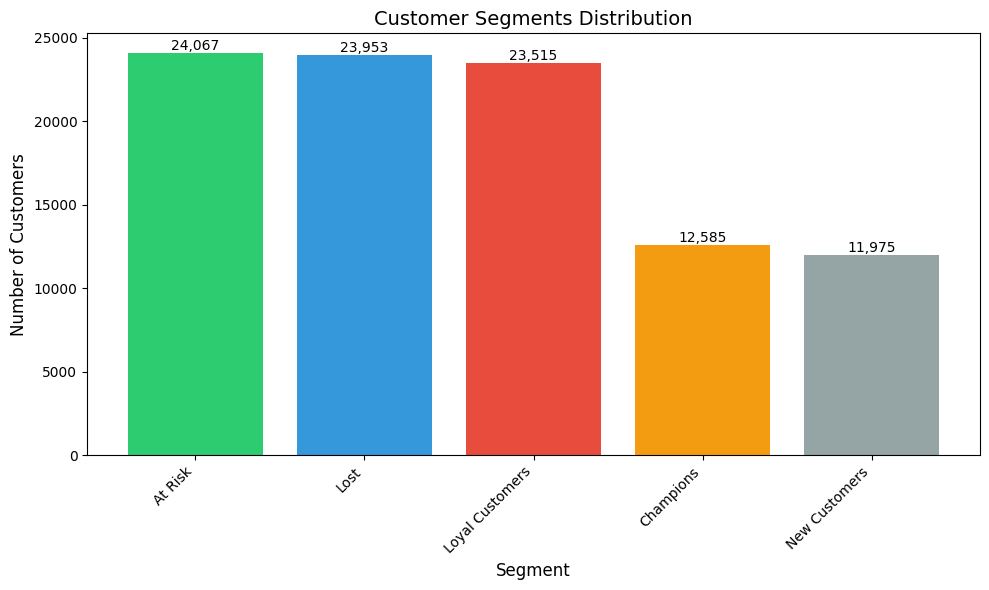

In [33]:
plt.figure(figsize=(10, 6))
segment_counts = rfm_table['Segment'].value_counts()
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#95a5a6']
bars = plt.bar(segment_counts.index, segment_counts.values, color=colors)
plt.title('Customer Segments Distribution', fontsize=14)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

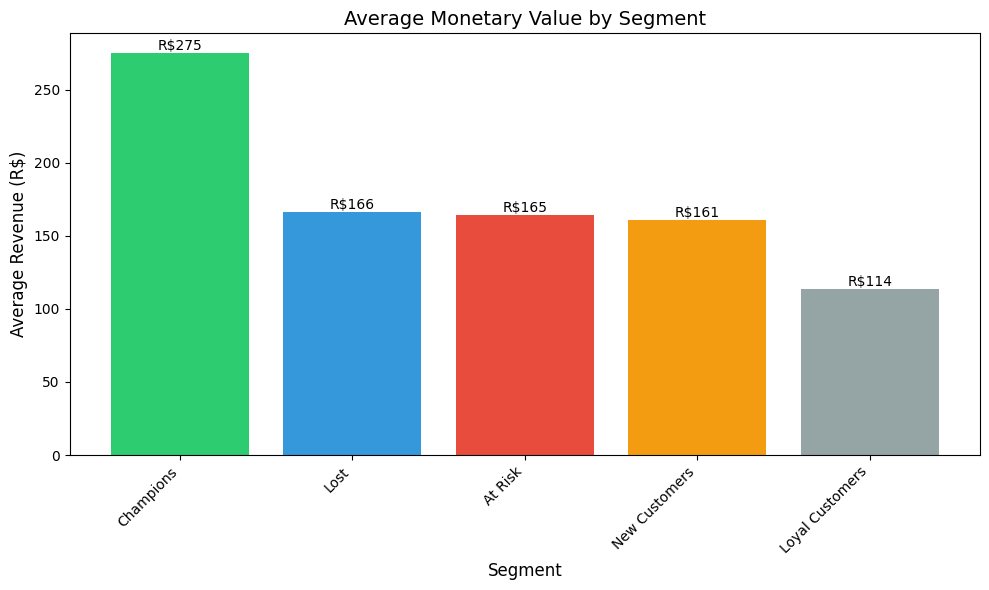

In [34]:
plt.figure(figsize=(10, 6))
segment_monetary = rfm_table.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
colors_monetary = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#95a5a6']
plt.bar(segment_monetary.index, segment_monetary.values, color=colors_monetary)
plt.title('Average Monetary Value by Segment', fontsize=14)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Average Revenue (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(segment_monetary.values):
    plt.text(i, v, f'R${v:.0f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Conclusions & Recommendations

The analysis identified 5 customer segments. The three largest — At Risk (24,067), Lost (23,953), and Loyal Customers (23,515) — are roughly equal in size, together accounting for ~75% of the customer base.

**Key finding:** At Risk and Lost segments combined represent ~R$8M in revenue that the business risks losing. Preventing the transition from At Risk to Lost is the highest priority.

**Recommendations by segment:**

| Priority | Segment | Action |
|----------|---------|--------|
| 🔴 **1** | **At Risk** | Launch re-engagement campaign — ~R$4M revenue at stake |
| 🟡 **2** | **Champions** | Develop a VIP retention strategy — highest average order value (R$275) |
| 🟡 **3** | **Loyal Customers** | Create an upgrade path to Champions via loyalty programme and cross-sell |
| 🟢 **4** | **Lost** | Win-back campaign only if economically viable (avg. Recency > 500 days) |